In [1]:
thelabel = " "
journal = "JHEP01 (2024) 066"

# Plot on the same canvas to have the same y axis reference

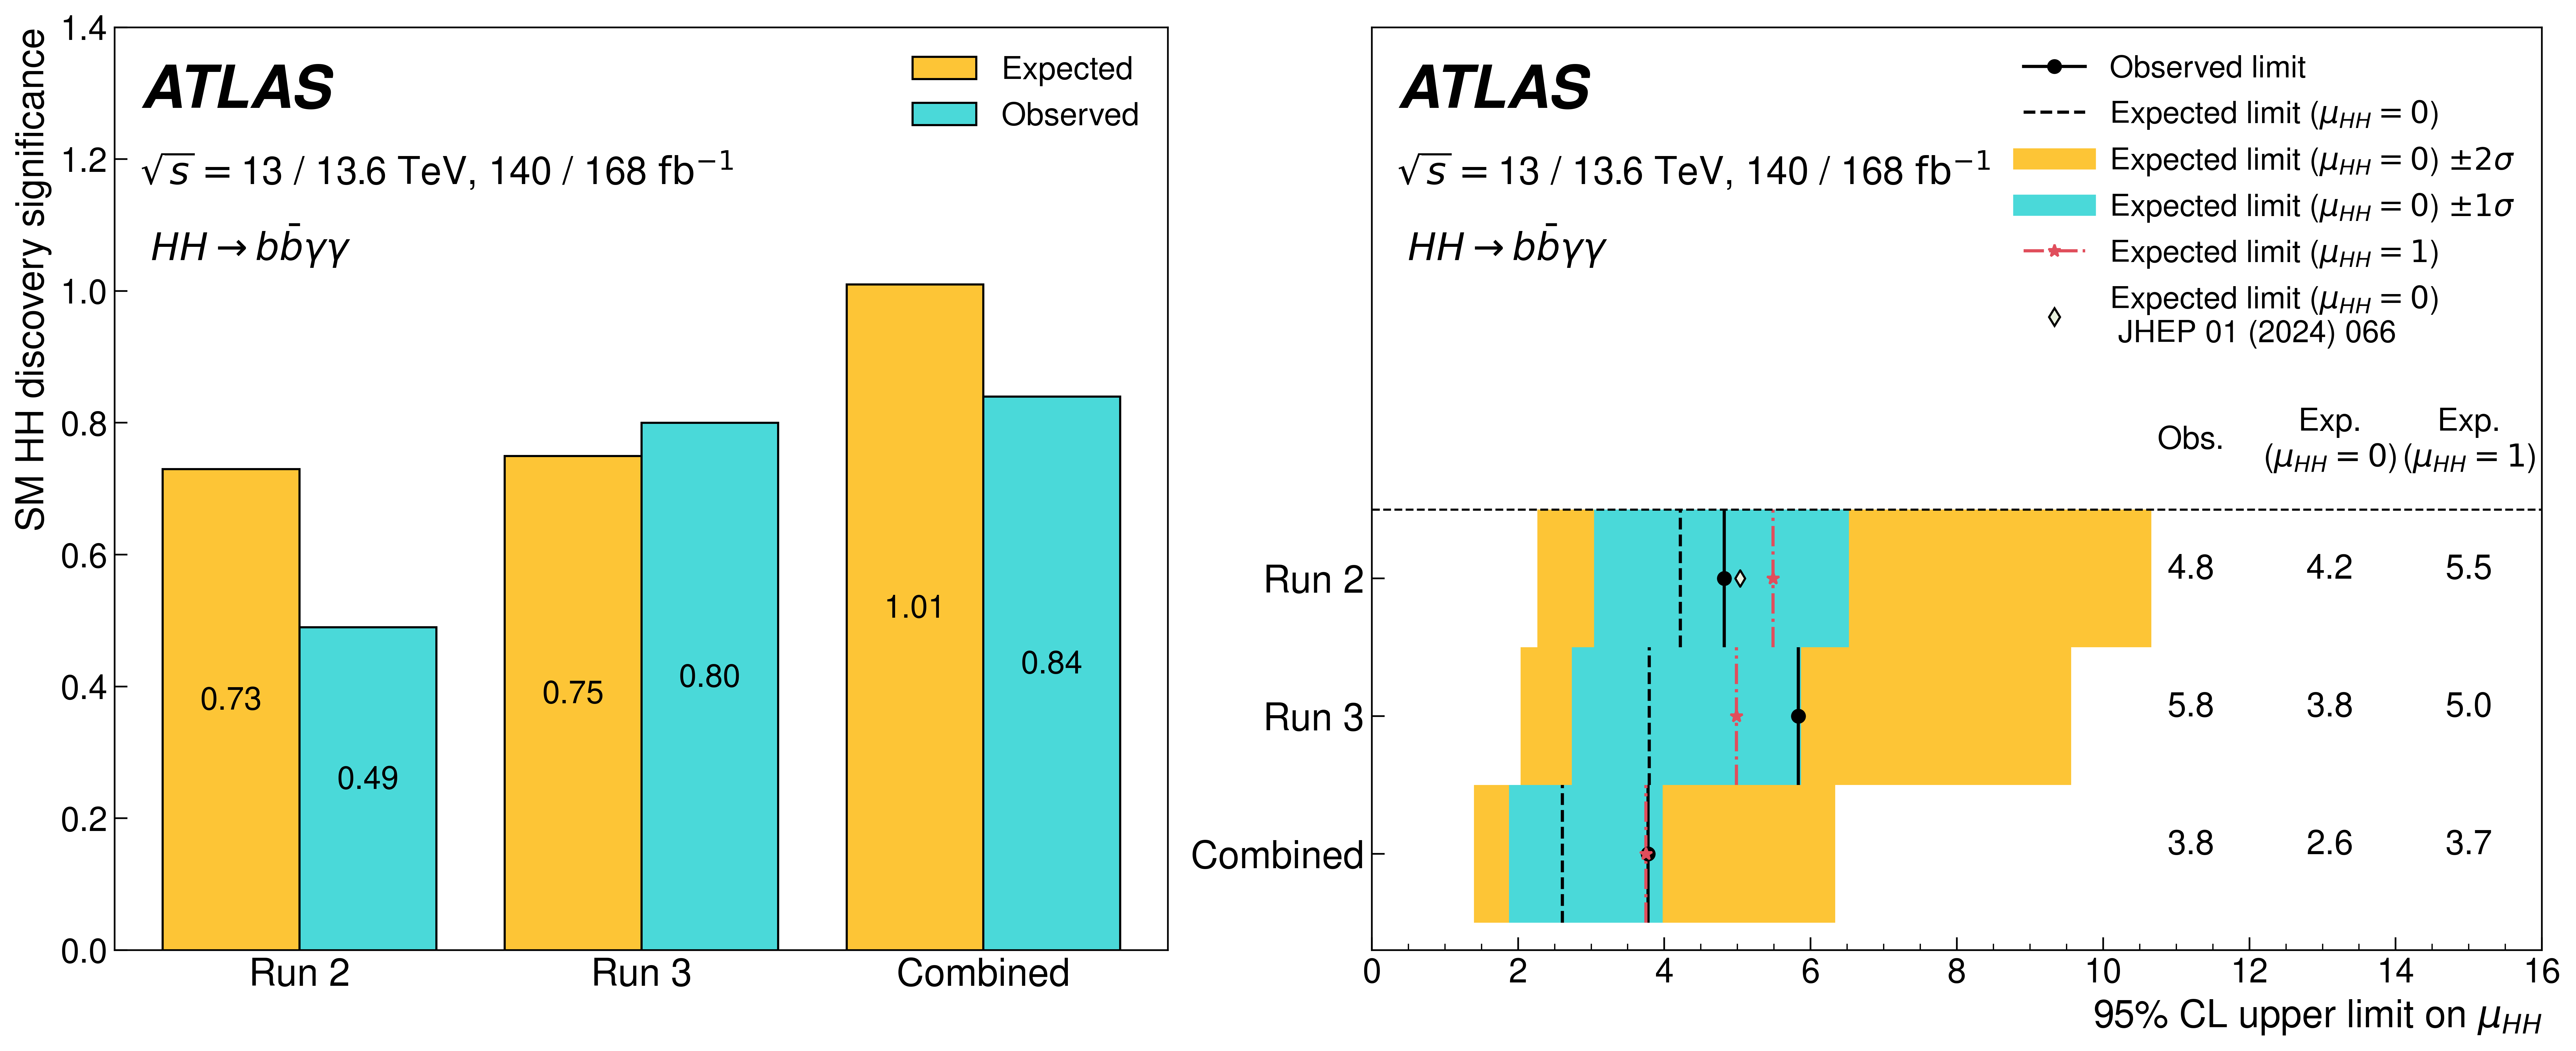

In [ ]:



import matplotlib.pyplot as plt
import numpy as np
import atlasify


fig1, (ax1,ax2) = plt.subplots(1, 2, figsize=(17, 7), dpi=500, gridspec_kw={'width_ratios': [0.9, 1]})
atlasify.ATLAS = "ATLAS"
atlasify.atlasify(thelabel, "$\\sqrt{s}=$13 / 13.6 TeV, 140 / 168 $\\text{fb}^{-1}$ \n $HH\\to b\\bar{b}\\gamma\\gamma$", axes=ax1,
        font_size=28, label_font_size=28, sub_font_size=18, line_spacing=2, indent=10, offset=10)
atlasify.ATLAS = "ATLAS"
atlasify.atlasify(thelabel, "$\\sqrt{s}=$13 / 13.6 TeV, 140 / 168 $\\text{fb}^{-1}$ \n $HH\\to b\\bar{b}\\gamma\\gamma$", axes=ax2,
        font_size=28, label_font_size=28, sub_font_size=18, line_spacing=2, indent=10, offset=10)

##################### FIG 1 #####################
labels = ['Run 2', 'Run 3', 'Combined']
expected_sig = [0.73, 0.75, 1.01]
observed_sig = [0.49, 0.80, 0.84]

x = np.arange(len(labels))
width = 0.4

ax1.bar(
    x - width / 2, expected_sig, width, label='Expected',
    color='#fdc536', edgecolor='black'
)
ax1.bar(
    x + width / 2, observed_sig, width, label='Observed',
    color='#4ad9d9', edgecolor='black'
)

# Annotate values
for i, (e, o) in enumerate(zip(expected_sig, observed_sig)):
    ax1.text(i - 0.2, e / 2, f'{e:.2f}', ha='center', fontsize=15)
    ax1.text(i + 0.2, o / 2, f'{o:.2f}', ha='center', fontsize=15)

ax1.set_ylabel('SM HH discovery significance', fontsize=18, loc="top")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=18)
ax1.set_ylim(0, 1.4)
ax1.legend(fontsize=15, loc='upper right', frameon=False)
ax1.tick_params(axis='x', bottom=False, top=False, which='both')
ax1.tick_params(axis='y', left=True, right=False, which='both')
ax1.tick_params(axis='y', which='minor', left=False)
ax1.tick_params(axis='y', labelsize=16)






####################### FIG 2 #######################


# Labels
labels = ['Run 2', 'Run 3', 'Combined']

# Data
obs_limits = [4.8189, 5.8316, 3.7781]
exp_limits = [4.2209, 3.7934, 2.6053]
exp_mu1 = [5.4869, 4.9860, 3.7467]
exp_1sig = [
    (3.0414, 6.5248),
    (2.7334, 5.8684),
    (1.8773, 3.9789)
]
exp_2sig = [
    (2.2655, 10.6573),
    (2.0360, 9.5615),
    (1.3984, 6.3375)
]
ylims = [(2,3), (1,2), (0,1)]
ycenter = [2.5, 1.5, 0.5]

y = np.arange(len(labels))[::-1]  # top to bottom


# Uncertainty bands (drawn as horizontal bars)
ax2.plot([], [], 'ko-', label='Observed limit', markersize=8, linewidth=1)
ax2.plot([], [], 'k--', label='Expected limit ($\\mu_{HH} = 0$)', markersize=8, linewidth=1)

for i in range(3):
    y_band = [ylims[i][0], ylims[i][1]]
    ax2.fill_betweenx(y_band, exp_2sig[i][0], exp_2sig[i][1], color='#fdc536', linewidth=0, 
        label='Expected limit ($\\mu_{HH} = 0$) $\pm$ 2$\sigma$' if i == 0 else "")

    ax2.fill_betweenx(y_band, exp_1sig[i][0], exp_1sig[i][1], color='#4ad9d9', linewidth=0, 
        label='Expected limit ($\\mu_{HH} = 0$) $\pm$ 1$\sigma$' if i == 0 else "")

    exp_errors_mu0 = np.array([[exp_limits[i] - exp_1sig[i][0], exp_1sig[i][1] - exp_limits[i]]])
    eb_expect_mu0=ax2.errorbar(
        exp_limits[i], ycenter[i],
        yerr=0.5,
        fmt='k',
        linestyle='--',
    )
    eb_expect_mu0[-1][0].set_linestyle('--')

    obs_errors = np.array([[obs_limits[i] - exp_1sig[i][0], exp_1sig[i][1] - obs_limits[i]]])
    eb_obs=ax2.errorbar(
        obs_limits[i], ycenter[i],
        yerr=0.5,
        fmt='k',
        marker='o',
        linestyle='--',
    )
    eb_obs[-1][0].set_linestyle('-')

    exp_errors_mu1 = np.array([[exp_mu1[i] - exp_1sig[i][0], exp_1sig[i][1] - exp_mu1[i]]])
    eb_expect_mu1=ax2.errorbar(
        exp_mu1[i], ycenter[i],
        yerr=0.5,
        linestyle='-.',
        color='#E04E5C',
        marker='*'
    )
    eb_expect_mu1[-1][0].set_linestyle('-.')



ax2.plot([], [], '*', label='Expected limit ($\\mu_{HH} = 1$)', markersize=8, color='#E04E5C', linestyle='-.', linewidth=1)

journal_name = "arXiv:2310.12301" if journal == "arxiv" else "JHEP 01 (2024) 066"

ax2.scatter(5.0341, 2.5, marker='d', color='#e9f1df', edgecolors='black', s=30, label="Expected limit ($\\mu_{HH} = 0$)\n"f"{journal_name}")


ax2.axhline(3, color='black', linestyle='--', linewidth=1)



# Add column headers
ax2.text(11.2, 3.5, "Obs.", fontsize=15, ha='center', va='center')
ax2.text(13.1, 3.5, "Exp.\n($\\mu_{HH}=0$)", fontsize=15, ha='center', va='center')
ax2.text(15, 3.5, "Exp.\n($\\mu_{HH}=1$)", fontsize=15, ha='center', va='center')

# Add values row by row
for i in range(3):
    ax2.text(11.2, ycenter[i], f"{obs_limits[i]:.1f}", fontsize=16, ha='center')
    ax2.text(13.1, ycenter[i], f"{exp_limits[i]:.1f}", fontsize=16, ha='center')
    ax2.text(15, ycenter[i], f"{exp_mu1[i]:.1f}", fontsize=16, ha='center')


# Aesthetics
ax2.set_yticks(ycenter)
ax2.set_yticklabels(labels, fontsize=18)
ax2.set_xlabel('95% CL upper limit on $\\mu_{HH}$', fontsize=18, loc="right")
ax2.set_xlim(0, 16)
ax2.set_ylim(-0.2, 6.5)

ax2.tick_params(axis='y', left=False, right=False, which='both')
ax2.tick_params(axis='y', which='major', left=True)
ax2.tick_params(axis='x', top=False, which='both')
ax2.tick_params(axis='x', labelsize=16)

# Legend
ax2.legend(fontsize=14.5, loc='upper right', frameon=False)
from matplotlib.lines import Line2D

# Create custom legend entries
legend_elements = [
    #Line2D([0], [0], color='none', label='Observed limit'),  # Group title (invisible line)
    Line2D([0], [0], color='black', marker='o', linestyle='-', label='Observed limit'),

    #Line2D([0], [0], color='none', label='Expected limits'),  # Group title (invisible line)
    Line2D([0], [0], color='black', linestyle='--', label=r'Expected limit ($\mu_{HH} = 0$)'),
    Line2D([0], [0], color='#fdc536', lw=10, label=r'Expected limit ($\mu_{HH} = 0$) $\pm 2\sigma$'),  # wide band
    Line2D([0], [0], color='#4ad9d9', lw=10, label=r'Expected limit ($\mu_{HH} = 0$) $\pm 1\sigma$'),
    Line2D([0], [0], color='#E04E5C', marker='*', linestyle='-.', label=r'Expected limit ($\mu_{HH} = 1$)'),
    Line2D([0], [0], marker='d', linestyle='None', color='#e9f1df', markeredgecolor='black', label=r'Expected limit ($\mu_{HH} = 0$) ''\n ' + journal_name),
]

ax2.legend(handles=legend_elements, fontsize=14.5, loc='upper right', frameon=False)

fig1.tight_layout()

fig1.savefig(f"./PlotFigures/FIGURES.png", dpi=500)
fig1.savefig(f"./PlotFigures/FIGURES.pdf", dpi=500)


In [5]:
!pip install PyMuPDF

In [7]:
import fitz  # PyMuPDF

def split_pdf_vertically(input_pdf, output_left, output_right):
    doc = fitz.open(input_pdf)
    left_doc = fitz.open()
    right_doc = fitz.open()

    for page in doc:
        rect = page.rect
        mid_x = rect.width * 0.46
        print(mid_x, rect.width, rect.width- mid_x)
        # Aree di ritaglio sulla pagina originale
        left_clip  = fitz.Rect(0,       0, mid_x,    rect.height)
        right_clip = fitz.Rect(mid_x,    0, rect.width, rect.height)

        # Nuove pagine (dimensioni metà larghezza)
        left_page  = left_doc.new_page(width=mid_x, height=rect.height)
        right_page = right_doc.new_page(width=rect.width- mid_x, height=rect.height)

        # Target rectangle: posiziona sempre da (0,0) a (mid_x, height)
        target_lefrt  = fitz.Rect(0, 0, mid_x, rect.height)
        target_right = fitz.Rect(0, 0, rect.width - mid_x, rect.height)

        # Mostra (ritaglia+posiziona)
        left_page.show_pdf_page(target_lefrt, doc, page.number, clip=left_clip)
        right_page.show_pdf_page(target_right, doc, page.number, clip=right_clip)

    left_doc.save(output_left)
    right_doc.save(output_right)
    print(f"Salvati: {output_left}, {output_right}")

# Esempio di uso
split_pdf_vertically(
    "./PlotFigures/FIGURES.pdf",
    "significanceplot_ATLAS.pdf",
    "UpperLimits_ATLAS.pdf"
)

563.0400000000001 1224.0 660.9599999999999
Salvati: significanceplot_ATLAS.pdf, UpperLimits_ATLAS.pdf


In [133]:
from matplotlib.transforms import Bbox

# get the full figure size in inches
fig_w, fig_h = fig1.get_size_inches()
print(f"Figure size (inches): {fig_w} x {fig_h}")
# define left and right half bboxes (in inches, relative to figure origin)
left_bbox  = Bbox.from_bounds(0,      0, fig_w / 2, fig_h)
right_bbox = Bbox.from_bounds(fig_w / 2, 0, fig_w, fig_h)

# now save each half
for name, bbox in zip(
    ['significanceplot', 'UpperLimits'],
    [left_bbox, right_bbox]
):
    fig1.savefig(f"./PlotFigures/Daje_{name}_{thelabel}.png",
                 bbox_inches=bbox, dpi=300)
    fig1.savefig(f"./PlotFigures/Daje_{name}_{thelabel}.pdf",
                 bbox_inches=bbox, dpi=300)

Figure size (inches): 17.0 x 7.0
